In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Loading and preparing the dataset
df = pd.read_csv('tech_roles_trends.csv')
df['Week'] = pd.to_datetime(df['Week'])
df.set_index('Week', inplace=True)
df.sort_index(inplace=True)

# Train test split
train = df.iloc[:-52]
test = df.iloc[-52:]

# Fitting all 3 models again
model_da = ARIMA(train['Data Analyst'], order=(1,1,1))
result_da = model_da.fit()

model_se = ARIMA(train['Software Engineer'], order=(1,0,1))
result_se = model_se.fit()

model_cs = ARIMA(train['Cybersecurity Specialist'], order=(1,0,1))
result_cs = model_cs.fit()

print(" Data loaded and models fitted!")

 Data loaded and models fitted!


## First part of Question 3 :Residual Analysis

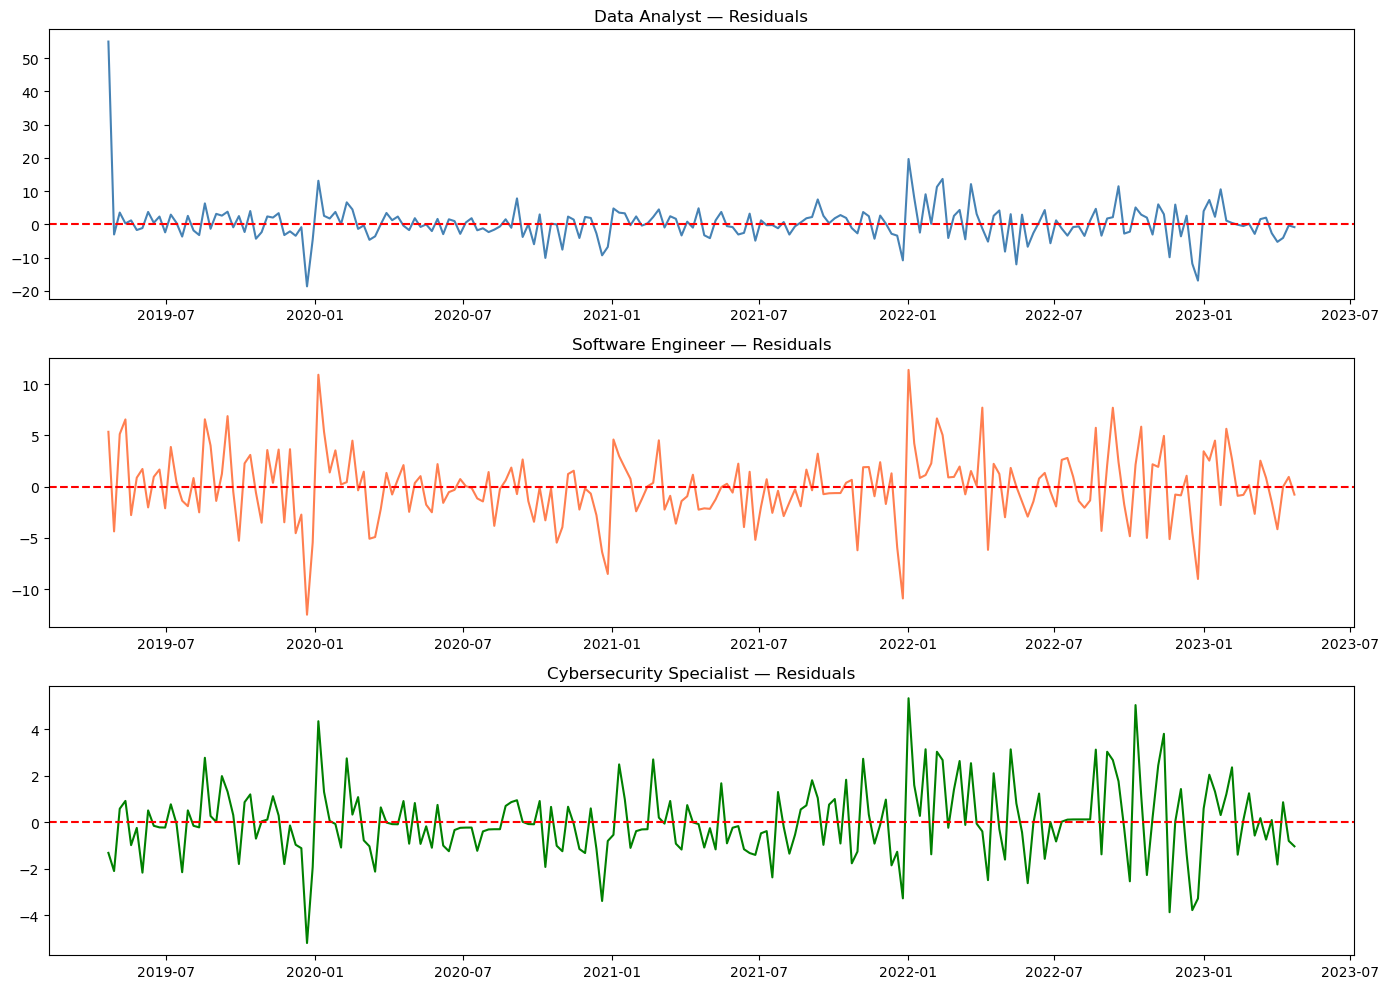

In [3]:
# Plotting residuals for all 3 models
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(result_da.resid, color='steelblue')
axes[0].set_title('Data Analyst — Residuals')
axes[0].axhline(y=0, color='red', linestyle='--')

axes[1].plot(result_se.resid, color='coral')
axes[1].set_title('Software Engineer — Residuals')
axes[1].axhline(y=0, color='red', linestyle='--')

axes[2].plot(result_cs.resid, color='green')
axes[2].set_title('Cybersecurity Specialist — Residuals')
axes[2].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

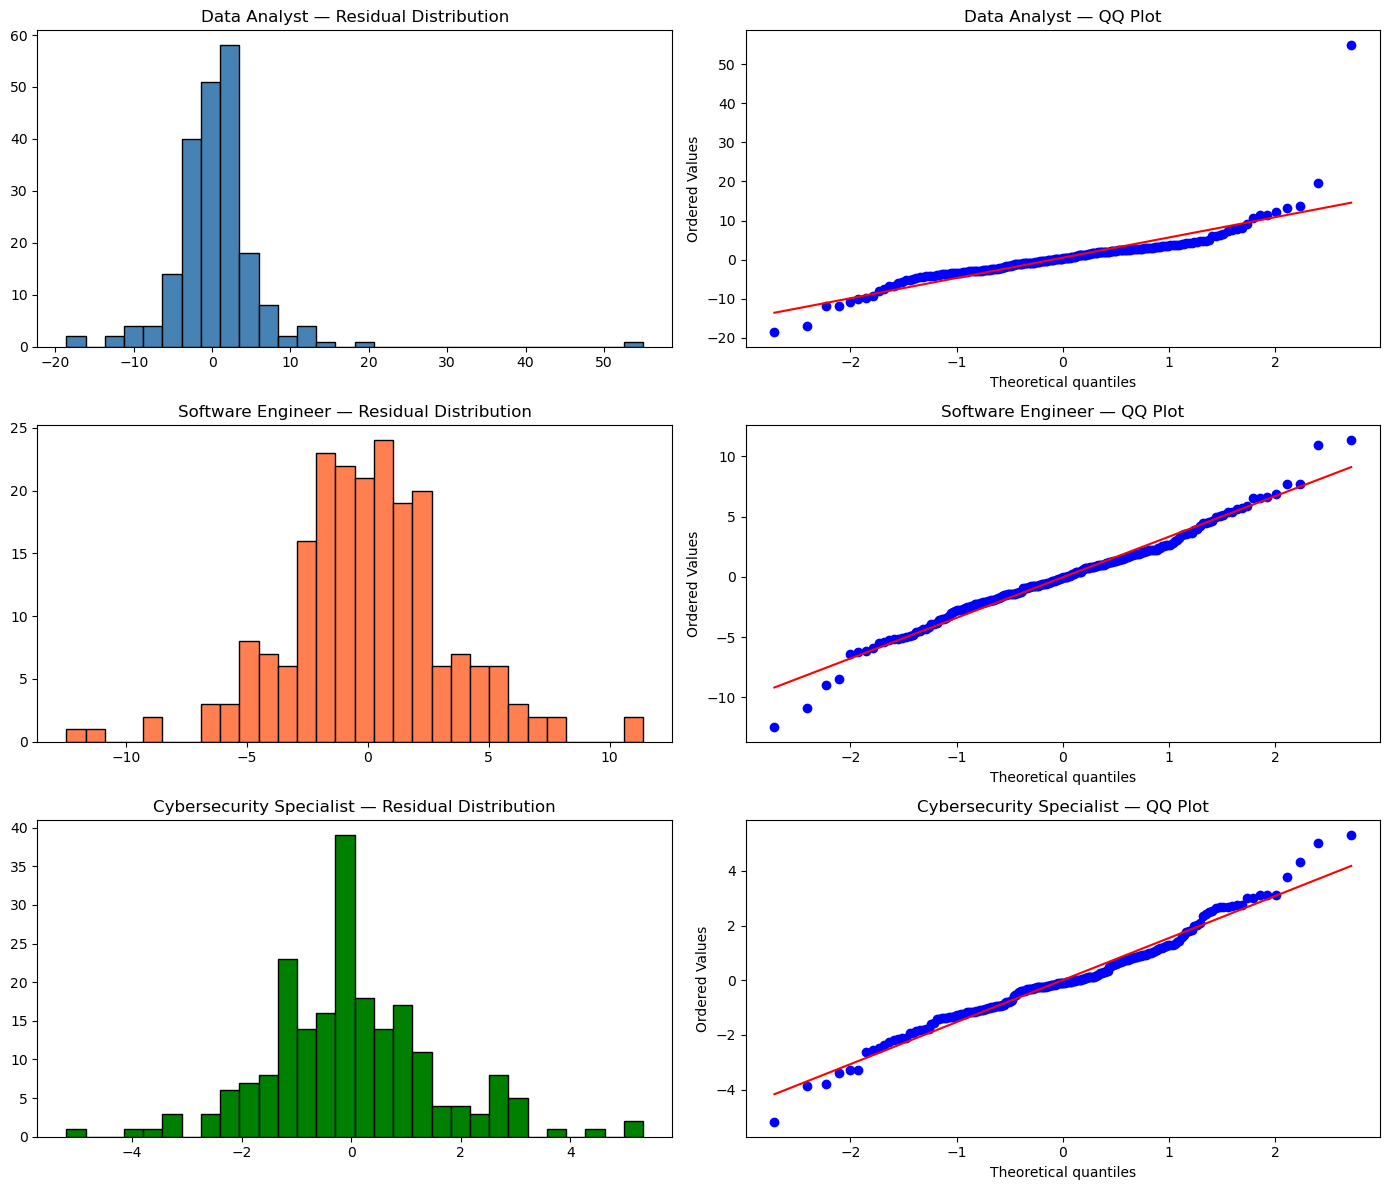

In [4]:
# Plotting residual distributions to check normality
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Data Analyst
axes[0,0].hist(result_da.resid, bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('Data Analyst — Residual Distribution')
stats.probplot(result_da.resid, plot=axes[0,1])
axes[0,1].set_title('Data Analyst — QQ Plot')

# Software Engineer
axes[1,0].hist(result_se.resid, bins=30, color='coral', edgecolor='black')
axes[1,0].set_title('Software Engineer — Residual Distribution')
stats.probplot(result_se.resid, plot=axes[1,1])
axes[1,1].set_title('Software Engineer — QQ Plot')

# Cybersecurity Specialist
axes[2,0].hist(result_cs.resid, bins=30, color='green', edgecolor='black')
axes[2,0].set_title('Cybersecurity Specialist — Residual Distribution')
stats.probplot(result_cs.resid, plot=axes[2,1])
axes[2,1].set_title('Cybersecurity Specialist — QQ Plot')

plt.tight_layout()
plt.show()

## Second part of Question 3 : Model Adequacy Checks

In [6]:
# Ljung-Box test to check if residuals are white noise
# p-value > 0.05 means residuals are white noise which is goodd

from statsmodels.stats.diagnostic import acorr_ljungbox

print(" Ljung-Box Test Results ")
print("\nData Analyst:")
lb_da = acorr_ljungbox(result_da.resid, lags=[10], return_df=True)
print(lb_da)

print("\nSoftware Engineer:")
lb_se = acorr_ljungbox(result_se.resid, lags=[10], return_df=True)
print(lb_se)

print("\nCybersecurity Specialist:")
lb_cs = acorr_ljungbox(result_cs.resid, lags=[10], return_df=True)
print(lb_cs)

 Ljung-Box Test Results 

Data Analyst:
     lb_stat  lb_pvalue
10  2.985318   0.981767

Software Engineer:
      lb_stat  lb_pvalue
10  13.109858   0.217594

Cybersecurity Specialist:
     lb_stat  lb_pvalue
10  19.23277   0.037404


## Third Part of Question 3 : Forecasting Next 12 Weeks

In [7]:
# Getting forecast with confidence intervals for next 12 weeks
forecast_da_full = result_da.get_forecast(steps=12)
forecast_se_full = result_se.get_forecast(steps=12)
forecast_cs_full = result_cs.get_forecast(steps=12)

# Getting confidence intervals
da_ci = forecast_da_full.conf_int()
se_ci = forecast_se_full.conf_int()
cs_ci = forecast_cs_full.conf_int()

da_mean = forecast_da_full.predicted_mean
se_mean = forecast_se_full.predicted_mean
cs_mean = forecast_cs_full.predicted_mean

print(" 12 week forecasts generated!")
print("\nData Analyst next 12 weeks:")
print(da_mean)

 12 week forecasts generated!

Data Analyst next 12 weeks:
2023-04-30    81.604503
2023-05-07    81.956356
2023-05-14    82.161152
2023-05-21    82.280355
2023-05-28    82.349737
2023-06-04    82.390120
2023-06-11    82.413626
2023-06-18    82.427307
2023-06-25    82.435271
2023-07-02    82.439906
2023-07-09    82.442604
2023-07-16    82.444174
Freq: W-SUN, Name: predicted_mean, dtype: float64


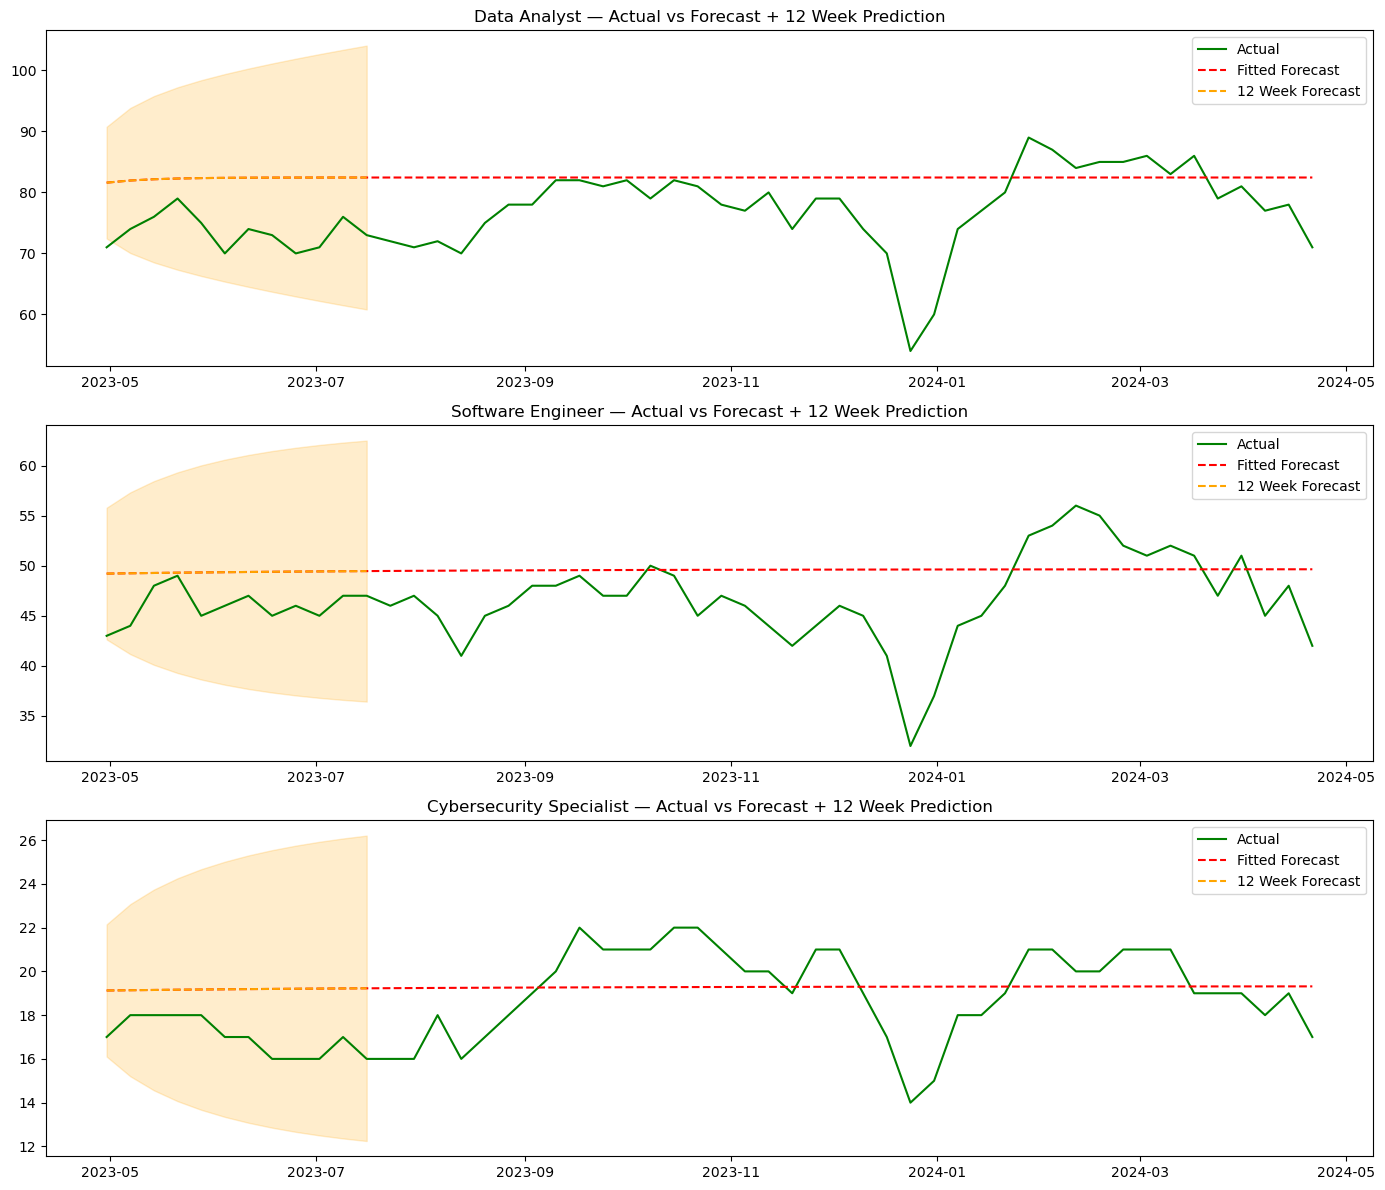

In [8]:
# Plotting forecasted vs actual + 12 week future forecast
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Data Analyst
axes[0].plot(test.index, test['Data Analyst'], color='green', label='Actual')
axes[0].plot(test.index, result_da.forecast(steps=52), color='red', linestyle='--', label='Fitted Forecast')
axes[0].plot(da_mean.index, da_mean, color='orange', linestyle='--', label='12 Week Forecast')
axes[0].fill_between(da_ci.index, da_ci.iloc[:,0], da_ci.iloc[:,1], alpha=0.2, color='orange')
axes[0].set_title('Data Analyst — Actual vs Forecast + 12 Week Prediction')
axes[0].legend()

# Software Engineer
axes[1].plot(test.index, test['Software Engineer'], color='green', label='Actual')
axes[1].plot(test.index, result_se.forecast(steps=52), color='red', linestyle='--', label='Fitted Forecast')
axes[1].plot(se_mean.index, se_mean, color='orange', linestyle='--', label='12 Week Forecast')
axes[1].fill_between(se_ci.index, se_ci.iloc[:,0], se_ci.iloc[:,1], alpha=0.2, color='orange')
axes[1].set_title('Software Engineer — Actual vs Forecast + 12 Week Prediction')
axes[1].legend()

# Cybersecurity Specialist
axes[2].plot(test.index, test['Cybersecurity Specialist'], color='green', label='Actual')
axes[2].plot(test.index, result_cs.forecast(steps=52), color='red', linestyle='--', label='Fitted Forecast')
axes[2].plot(cs_mean.index, cs_mean, color='orange', linestyle='--', label='12 Week Forecast')
axes[2].fill_between(cs_ci.index, cs_ci.iloc[:,0], cs_ci.iloc[:,1], alpha=0.2, color='orange')
axes[2].set_title('Cybersecurity Specialist — Actual vs Forecast + 12 Week Prediction')
axes[2].legend()

plt.tight_layout()
plt.show()

In [9]:
# Calculating forecast accuracy metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

forecast_da_test = result_da.forecast(steps=52)
forecast_se_test = result_se.forecast(steps=52)
forecast_cs_test = result_cs.forecast(steps=52)

def accuracy_metrics(actual, forecast, name):
    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    print(f"\n=== {name} ===")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

accuracy_metrics(test['Data Analyst'], forecast_da_test, 'Data Analyst')
accuracy_metrics(test['Software Engineer'], forecast_se_test, 'Software Engineer')
accuracy_metrics(test['Cybersecurity Specialist'], forecast_cs_test, 'Cybersecurity Specialist')


=== Data Analyst ===
MSE:  71.5340
RMSE: 8.4578
MAE:  6.5780
MAPE: 9.24%

=== Software Engineer ===
MSE:  25.5784
RMSE: 5.0575
MAE:  4.0468
MAPE: 9.29%

=== Cybersecurity Specialist ===
MSE:  4.3289
RMSE: 2.0806
MAE:  1.7628
MAPE: 9.95%


## Last Part: Methodology Justification



### Model Selection
ARIMA was selected 
as the forecasting model for all three job roles. This choice 
is justified by the following reasons:

1. The data is weekly time series data with clear trends and 
some seasonal patterns, and ARIMA handles that well.

2. The ACF and PACF plots clearly showed autoregressive and 
moving average patterns suitable for ARIMA modelling.

3. Stationarity tests confirmed that the series could be made 
stationary through differencing, which is a key requirement 
for ARIMA models.

### Model Parameters
- Data Analyst: ARIMA(1,1,1) — required differencing (d=1) 
  since it was non-stationary. ACF and PACF suggested p=1, q=1.

- Software Engineer: ARIMA(1,0,1) — already stationary (d=0). 
  PACF cut off after lag 1 suggesting p=1, ACF suggested q=1.

- Cybersecurity Specialist: ARIMA(1,0,1) — already stationary 
  (d=0). Similar ACF and PACF pattern to Software Engineer.

### Model Performance
All three models achieved a MAPE of around 9-10% which is 
acceptable for weekly search trend data. The residual analysis 
confirmed that residuals were approximately white noise for 
Data Analyst and Software Engineer which indicates good model fit.
